In [1]:
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;

In [2]:
df=pd.read_csv("Downloads/Real estate.csv")

In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.shape

(414, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [7]:
df = df.set_index('No', drop=True)

In [8]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,,,,,,,
1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [9]:
df.isnull().sum() #no null values

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [10]:
df.duplicated().sum() #no duplicates

0

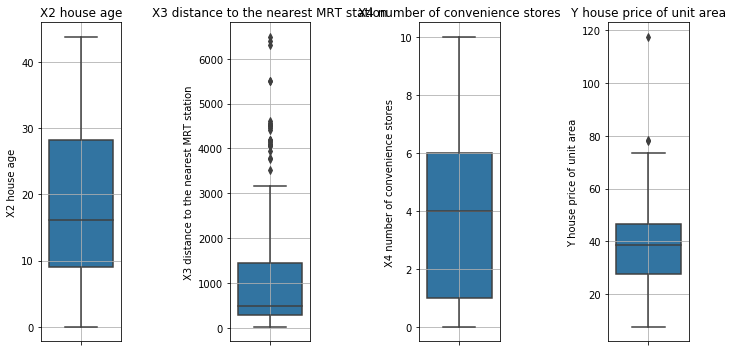

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

# Boxplot1
sns.boxplot(y=df['X2 house age'], ax=axes[0])
axes[0].set_title('X2 house age')
axes[0].grid(True)

# Boxplot2
sns.boxplot(y=df['X3 distance to the nearest MRT station'], ax=axes[1])
axes[1].set_title('X3 distance to the nearest MRT station')
axes[1].grid(True)

# Boxplot3
sns.boxplot(y=df['X4 number of convenience stores'], ax=axes[2])
axes[2].set_title('X4 number of convenience stores')
axes[2].grid(True)

# Boxplot4
sns.boxplot(y=df['Y house price of unit area'], ax=axes[3])
axes[3].set_title('Y house price of unit area')
axes[3].grid(True)


plt.tight_layout()
plt.show()

In [12]:
#outliers are there in the X3 distance to MRTS column,target variable

In [13]:
q1=df['X3 distance to the nearest MRT station'].quantile(0.25)
q2=df['X3 distance to the nearest MRT station'].quantile(0.5)
q3=df['X3 distance to the nearest MRT station'].quantile(0.75)
IQR=q3-q1
# Step 2: Define outlier boundaries
lower_bound = q1 - 1.5 * IQR #
upper_bound = q3 + 1.5 * IQR
#step 3 : filter outliers
outliers = df[(df['X3 distance to the nearest MRT station'] < lower_bound) | (df['X3 distance to the nearest MRT station'] > upper_bound)]
print(outliers.count())

X1 transaction date                       37
X2 house age                              37
X3 distance to the nearest MRT station    37
X4 number of convenience stores           37
X5 latitude                               37
X6 longitude                              37
Y house price of unit area                37
dtype: int64


In [14]:
# we have 37 outliers in the dataset

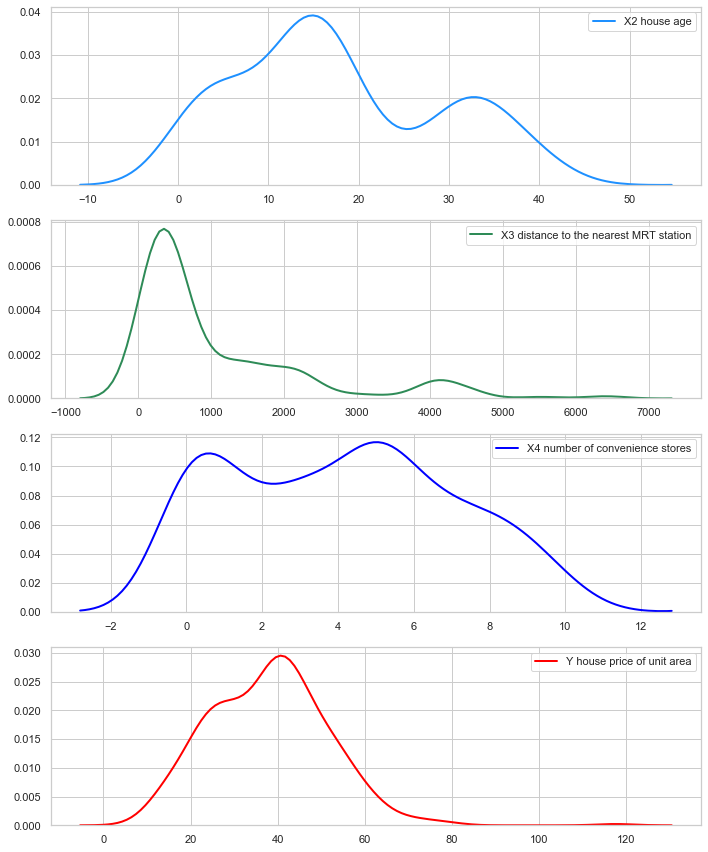

In [15]:
#plotting KDE plot
sns.set(style='whitegrid')

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=False)
sns.kdeplot(df['X2 house age'],linewidth=2, ax=axes[0], color='dodgerblue')
sns.kdeplot(df['X3 distance to the nearest MRT station'],  linewidth=2, ax=axes[1], color='seagreen')
sns.kdeplot(df['X4 number of convenience stores'], linewidth=2, ax=axes[2], color='blue')
sns.kdeplot(df['Y house price of unit area'],linewidth=2,ax=axes[3],color='red')
plt.tight_layout()
plt.show()

In [16]:
#X3 distance to the nearest MRT station column is right sckewed as we can see from kde plot

In [17]:
df['X3 distance to the nearest MRT station'].skew()

1.8887565801256057

In [18]:
 # create a model with outliers first and evaluate the performance

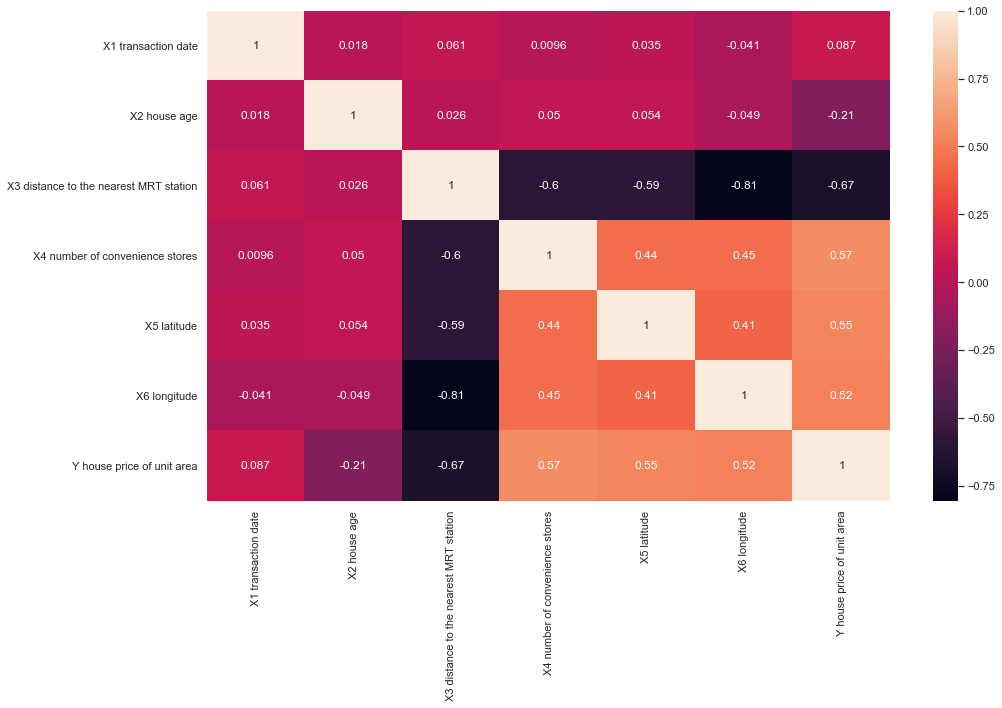

In [19]:
df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.tight_layout()
plt.show()

In [20]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [21]:
X=df.drop('Y house price of unit area',axis=1)
y=df['Y house price of unit area']

In [22]:
#data split into train & test
from sklearn.model_selection import train_test_split
#applying log transformation
X_log=np.log1p(X)
y_log=np.log1p(y)
X_train,X_test,y_train,y_test=train_test_split(X_log,y_log,test_size=0.2,random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(331, 6)
(83, 6)
(331,)
(83,)


In [24]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [25]:
y_pred=model.predict(X_test)

In [26]:
df_preds=pd.DataFrame()
df_preds['actual_price'] = y_test.squeeze()
df_preds['predicted_price'] = y_pred.squeeze()
df_preds['difference']=df_preds['predicted_price']-df_preds['actual_price']

In [27]:
print(df_preds)

     actual_price  predicted_price  difference
No                                            
359      3.830813         3.962052    0.131239
351      3.768153         3.592673   -0.175480
374      3.974058         3.969537   -0.004521
400      3.645450         3.772150    0.126700
370      3.169686         3.177003    0.007317
..            ...              ...         ...
32       3.258097         3.585464    0.327368
284      3.198673         3.496017    0.297344
158      3.600048         3.652947    0.052899
204      3.852273         3.781913   -0.070360
209      3.303217         3.242698   -0.060519

[83 rows x 3 columns]


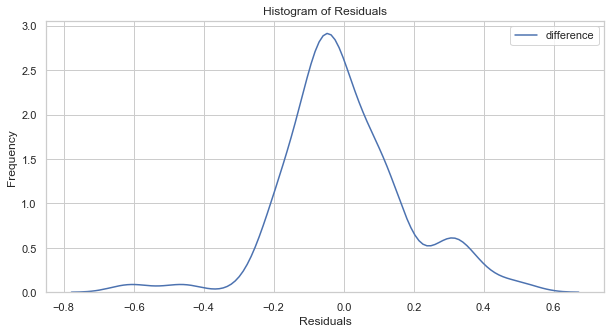

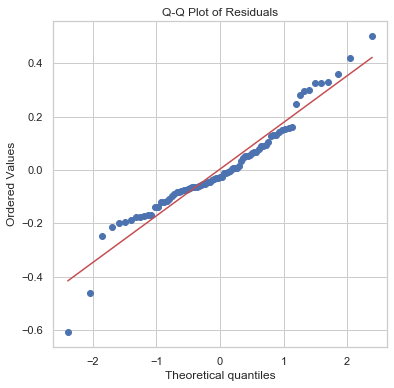

In [28]:
# Lets check for normality of residuals using Histogram or Q-Q plots
# Histogram: Should resemble a bell curve if residuals are normally distributed.
# Q-Q plot: Points should lie roughly on the diagonal line. Major deviations suggest non-normality.
plt.figure(figsize=(10, 5))
sns.kdeplot(df_preds['difference'])
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Q-Q plot of residuals
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(df_preds['difference'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

In [29]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
MEA=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_pred)
print(f"MEA:{MEA}")
print(f"MSE:{MSE}")
print(f"RMSE:{RMSE}")
print(f"R2:{R2}")

MEA:0.12907253214370656
MSE:0.03109669815423666
RMSE:0.17634255911219124
R2:0.7973248054473421


#R² close to 0.8 → good explanatory power
#RMSE relatively small → accurate predictions
#No large gap between MAE and RMSE → few extreme errors

In [30]:
#model performs really bad with outliers, but after applying log transfromation performance got improved.

In [31]:
#lets tackle outliers from the dataset
#determining outliers using Z-score
from scipy import stats
z_score=np.abs(stats.zscore(df['X3 distance to the nearest MRT station']))
#print(z_score)
df_clean=df[z_score<3]

In [32]:
df_clean.duplicated().sum()

0

In [33]:
df_clean.shape

(409, 7)

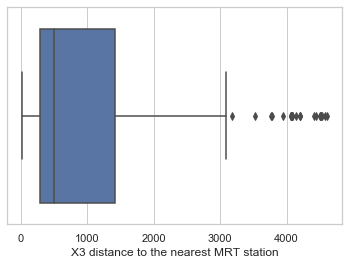

In [34]:
sns.boxplot(df_clean['X3 distance to the nearest MRT station'])
plt.show()

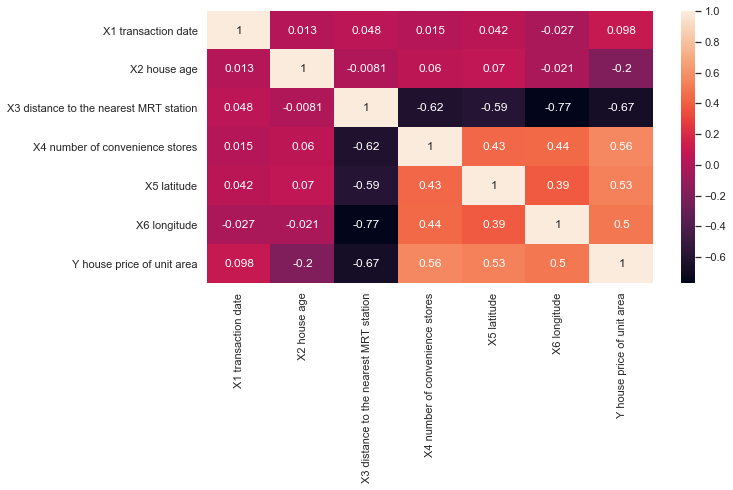

In [35]:
df_clean.corr()
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.corr(),annot=True)
plt.show()

In [36]:
X=df_clean.drop('Y house price of unit area',axis=1)
y=df_clean['Y house price of unit area']

In [37]:
#data split after removing outliers
from sklearn.model_selection import train_test_split
#applying log transformation here to improve the model performance and since the distance column has right scewed data,
#to deal with it we are applying log transformation technique 
X_log=np.log1p(X)
y_log=np.log1p(y)
X_train,X_test,y_train,y_test=train_test_split(X_log,y_log,test_size=0.2,random_state=42)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(327, 6)
(82, 6)
(327,)
(82,)


In [39]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [40]:
y_predi=model.predict(X_test)

In [41]:
df_predict=pd.DataFrame()
df_predict['áctual_value']=y_test.squeeze()
df_predict['predict_value']=y_predi.squeeze()
df_predict['difference']=y_predi-y_test
print(df_predict)

     áctual_value  predict_value  difference
No                                          
175      3.832980       3.928372    0.095392
140      3.772761       3.537732   -0.235029
129      4.122284       3.741182   -0.381102
96       3.966511       3.871956   -0.094555
74       3.044522       2.876126   -0.168397
..            ...            ...         ...
155      3.077312       2.925498   -0.151814
6        3.499533       3.253966   -0.245568
47       3.761200       3.721364   -0.039836
95       3.737670       3.657860   -0.079810
289      3.951244       3.875396   -0.075848

[82 rows x 3 columns]


In [42]:
#model evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
MAE=mean_absolute_error(y_test,y_predi)
MSE=mean_squared_error(y_test,y_predi)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_predi)
print(MAE)
print(MSE)
print(RMSE)
print(R2)

0.15376136705487845
0.04592009429471833
0.2142897437926471
0.7043788598343361


In [43]:
#After removing outliers the model performance is bad compared to with outliers data set

## Observations

#Before removing outliers & before applying log transformation the model performance is bad
#Before removing outliers & after applying log transformation the model performance has improved a lot
#After removing outliers & before applying log transformation the model performance is worse than 1st case
#After removing outliers & after applying log transformation the model performance is still worse than 1st case but btr than 3rd case.

#After removing outliers we might be loosing some data. so, removing outliers is not a good idea. Instead to deal with rightly-sckwed data we have to use log transformation